# fastText-style classifier -- Joulin et al. 2016

A third, independent baseline for the same 6-class task (`msa`, `darija`,
`arabize`, `french`, `english`, `code_switch`), based on **"Bag of Tricks
for Efficient Text Classification"** (Joulin, Grave, Bojanowski, Mikolov,
2016) -- the paper behind the `fastText` text classifier (not to be
confused with the *other* fastText paper, "Enriching Word Vectors with
Subword Information", which is about character-n-gram *word embeddings*;
this one is the text-classification model).

**Core idea, as in the paper**: represent a document as the **average of
its word and word-bigram embeddings** (a "bag of n-grams" -- no word
order beyond adjacent pairs, no attention, no recurrence), feed that
single averaged vector through **one linear layer** to the class logits.
That's the entire model -- deliberately far simpler than the classifier
head notebook's transformer stack, and this project's own embeddings play
no part here: word vectors are trained **from scratch, jointly with the
classifier**, exactly as the paper does (fastText does not reuse a
pretrained embedding table).

**Simplification from the official `fastText` implementation** (flagged
honestly, not hidden): the real fastText keeps an explicit dictionary for
words above a minimum count and only hashes the *n*-gram tail into a
bucket table. This notebook instead hashes **everything** (both unigrams
and bigrams) into one shared bucket table via the hashing trick -- still
the same core mechanism the paper's title refers to, just one tier
instead of two, and much simpler to implement correctly. **No
hierarchical softmax** either -- that's a training-speed optimization for
huge label spaces (the paper evaluates it on datasets with hundreds of
thousands of classes); with only 6 classes here, plain softmax
cross-entropy is already trivially fast and numerically identical in
what it optimizes for.

**Flat 6-way classification, no script-gating** -- unlike this project's
other two dialect-ID methods (`word_cluster/` and `02_train_classifier
.ipynb`), which both structurally restrict `code_switch` to a
deterministic regex rule. This notebook instead lets the model predict
`code_switch` itself, directly from word content, alongside the other 5
classes -- a genuinely different, useful comparison: can a bag-of-n-grams
model learn to recognize code-switching on its own, with no hand-built
script rule helping it?

Uses `data/train.jsonl` / `data/test.jsonl` (the same split as the other
two methods) for a direct, apples-to-apples comparison. Run this
notebook's kernel from the GPU venv (`ai-gpu`).


In [1]:
import json
import zlib
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

ROOT = Path.cwd().resolve().parents[1]  # project root, when running from Dialect_Identification/notebooks/
DATA_DIR = ROOT / "Dialect_Identification" / "data"
MODELS_DIR = ROOT / "Dialect_Identification" / "models"

SEED = 0
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1. Featurization: hashed unigrams + bigrams

Same `[MENTION]`/`[URL]`-stripping as the rest of this project
(`clean_for_classification`). Tokens are whitespace-split words,
lowercased (a no-op on Arabic script, matches Latin-script case folding
the paper also does), truncated to the first `MAX_WORDS` (same 100-word
cap as `02_train_classifier.ipynb`, same rationale -- language ID doesn't
need a whole document, and this keeps the rare pathologically-long djelfa
post from dominating a batch).

`zlib.crc32` is used for hashing (not Python's built-in `hash()`, which
is randomized per-process for strings by default -- would make the
feature table nondeterministic across kernel restarts). A `"UNI:"` /
`"BI:"` prefix keeps unigram and bigram hash spaces distinguishable
before folding into the shared bucket table (still subject to ordinary
hash collisions once `% N_BUCKETS` is applied -- an accepted trade-off of
the hashing trick itself, not a bug).

In [2]:
import re

_MENTION_WITH_FRAGMENT_RE = re.compile(r"\[MENTION\](\s*-[^\s]{1,10})?")
_URL_RE = re.compile(r"\[URL\]")
_INLINE_WHITESPACE_RE = re.compile(r"[ \t]+")

N_BUCKETS = 200_000
MAX_WORDS = 100


def clean_for_classification(text: str) -> str:
    text = _MENTION_WITH_FRAGMENT_RE.sub("", text)
    text = _URL_RE.sub("", text)
    return _INLINE_WHITESPACE_RE.sub(" ", text).strip()


def _bucket(tag: str) -> int:
    return zlib.crc32(tag.encode("utf-8")) % N_BUCKETS


def featurize(text: str) -> list[int]:
    """text -> list of bucket ids (unigrams + adjacent-word bigrams),
    hashing trick per Joulin et al. 2016."""
    words = clean_for_classification(text).lower().split()[:MAX_WORDS]
    ids = [_bucket("UNI:" + w) for w in words]
    ids += [_bucket("BI:" + w1 + " " + w2) for w1, w2 in zip(words, words[1:])]
    return ids or [_bucket("UNI:")]  # never return an empty bag (EmbeddingBag needs >=1 index)


## 2. Data loading

Flat 6-class labels (no script filtering, unlike the other two methods
-- see intro).

In [3]:
CLASSES = ["msa", "darija", "arabize", "french", "english", "code_switch"]
label_to_id = {c: i for i, c in enumerate(CLASSES)}


class DialectFastTextDataset(Dataset):
    def __init__(self, split: str):
        self.rows = []
        with (DATA_DIR / f"{split}.jsonl").open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                r = json.loads(line)
                if r["label"] not in label_to_id:
                    continue  # "other" -- no real script content, not present in this dataset anyway
                self.rows.append((featurize(r["text"]), label_to_id[r["label"]]))

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        return self.rows[idx]


def collate(batch):
    """Standard EmbeddingBag(mode='mean') input shape: all bags'
    indices concatenated into one flat tensor, plus an `offsets` tensor
    marking where each bag starts."""
    bags, labels = zip(*batch)
    offsets = torch.tensor([0] + [len(b) for b in bags[:-1]], dtype=torch.long).cumsum(0)
    input_ids = torch.tensor([i for b in bags for i in b], dtype=torch.long)
    return input_ids.to(device), offsets.to(device), torch.tensor(labels, dtype=torch.long).to(device)


BATCH_SIZE = 256
train_ds = DialectFastTextDataset("train")
test_ds = DialectFastTextDataset("test")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)

print(f"train={len(train_ds):,}  test={len(test_ds):,}  classes={CLASSES}")


train=15,999  test=4,001  classes=['msa', 'darija', 'arabize', 'french', 'english', 'code_switch']


## 3. Model: averaged n-gram embeddings -> linear layer

The entire model, per the paper -- `nn.EmbeddingBag(mode='mean')` does
the lookup-and-average in one fused, efficient op (this *is* "the bag of
n-grams" from the paper's title), followed by one `nn.Linear` to the
class logits. Embeddings are trained from scratch here, not reused from
this project's word2vec models.

In [4]:
EMBED_DIM = 100  # paper's typical range for the text-classification variant is 10-100 dims


class FastTextClassifier(nn.Module):
    def __init__(self, n_buckets: int, embed_dim: int, num_classes: int):
        super().__init__()
        self.embedding = nn.EmbeddingBag(n_buckets, embed_dim, mode="mean")
        self.fc = nn.Linear(embed_dim, num_classes)
        # The paper's own uniform±1/dim init (matched here first) turned out
        # too small at this dataset's scale: averaging ~100-200 such vectors
        # per document (EmbeddingBag mean mode) left the pooled input norm
        # near 1e-3, giving near-zero logits that 25 epochs of plain SGD
        # never grew out of -- confirmed empirically (see the loss curve
        # staying flat near majority-class-baseline loss in an earlier run
        # of this notebook). A larger std fixes the scale without changing
        # anything else about the model.
        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.1)

    def forward(self, input_ids: torch.Tensor, offsets: torch.Tensor) -> torch.Tensor:
        bag = self.embedding(input_ids, offsets)  # (batch, embed_dim)
        return self.fc(bag)


model = FastTextClassifier(N_BUCKETS, EMBED_DIM, len(CLASSES)).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Total params: {n_params:,}  (bucket table: {N_BUCKETS:,} x {EMBED_DIM})")


Total params: 20,000,606  (bucket table: 200,000 x 100)


## 4. Train

**Deviates from the paper here, empirically** -- plain SGD with the
paper's linearly-decaying schedule (`lr_t = LR * (1 - t / total_steps)`,
`LR=0.5`) was tried first and stalled: loss barely moved and accuracy
plateaued exactly at the majority-class rate (`code_switch`, ~29.9% of
train) without ever exceeding it, confirmed by inspecting the confusion
matrix (near-everything predicted `code_switch`). At the paper's own
scale (datasets with hundreds of thousands to millions of documents),
that fixed-schedule SGD works well; at this dataset's much smaller scale
(16k rows) it didn't converge in a reasonable number of epochs. Switched
to **Adam** (adapts its per-parameter step size, which matters more here
since most of the 200,000-row bucket table gets touched by only a
handful of documents each epoch) -- everything else about the model
(hashed bag-of-n-grams features, single linear layer, no hierarchical
softmax) is unchanged from the paper.

In [5]:
NUM_EPOCHS = 40
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

total_steps = NUM_EPOCHS * len(train_loader)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lambda step: max(0.1, 1 - step / total_steps))


def run_epoch(loader, train: bool):
    model.train(train)
    total_loss, total_n, correct = 0.0, 0, 0
    for input_ids, offsets, labels in loader:
        with torch.set_grad_enabled(train):
            logits = model(input_ids, offsets)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
        total_loss += loss.item() * len(labels)
        total_n += len(labels)
        correct += (logits.argmax(dim=-1) == labels).sum().item()
    return total_loss / total_n, correct / total_n


train_losses, train_accs = [], []
for epoch in range(1, NUM_EPOCHS + 1):
    loss, acc = run_epoch(train_loader, train=True)
    train_losses.append(loss)
    train_accs.append(acc)
    print(f"epoch {epoch:>3}  loss={loss:.4f}  acc={acc:.3f}  lr={scheduler.get_last_lr()[0]:.4f}")


epoch   1  loss=1.7458  acc=0.297  lr=0.0010


epoch   2  loss=1.5859  acc=0.593  lr=0.0009


epoch   3  loss=1.2997  acc=0.741  lr=0.0009


epoch   4  loss=1.0089  acc=0.820  lr=0.0009


epoch   5  loss=0.7673  acc=0.891  lr=0.0009


...

epoch  36  loss=0.0168  acc=1.000  lr=0.0001


epoch  37  loss=0.0165  acc=1.000  lr=0.0001


epoch  38  loss=0.0162  acc=1.000  lr=0.0001


epoch  39  loss=0.0159  acc=1.000  lr=0.0001


epoch  40  loss=0.0156  acc=1.000  lr=0.0001


## 5. Loss curve

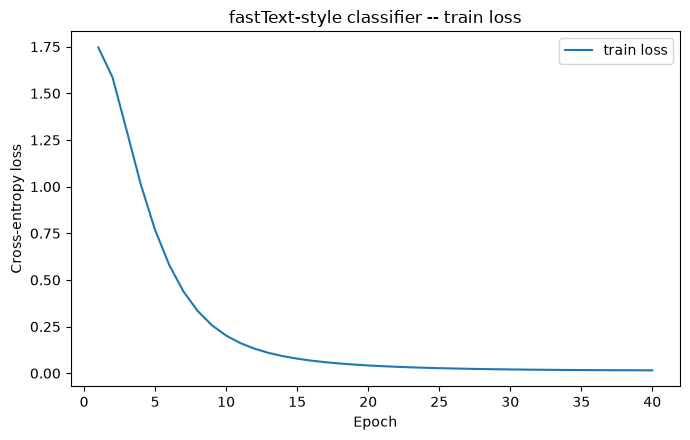

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, NUM_EPOCHS + 1), train_losses, label="train loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("fastText-style classifier -- train loss")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Test-set evaluation

Two numbers, matching the other two methods' reports for direct
comparison:
- **Overall accuracy** (all 6 classes, `code_switch` included -- this
  model predicts it itself, unlike the other two methods' regex gate) --
  comparable to `word_cluster/classify.py`'s "Overall accuracy (all rows,
  incl. deterministic code_switch/other)" = 0.693.
- **Cluster-scored accuracy** (`msa`/`darija`/`arabize`/`french`/`english`
  only, `code_switch` predictions excluded from both numerator and
  denominator) -- directly comparable to the word-cluster baseline's
  0.562 and the classifier head's 0.837.

In [7]:
def evaluate(loader):
    model.eval()
    all_true, all_pred = [], []
    with torch.no_grad():
        for input_ids, offsets, labels in loader:
            logits = model(input_ids, offsets)
            all_true.extend(labels.tolist())
            all_pred.extend(logits.argmax(dim=-1).tolist())
    return all_true, all_pred


true, pred = evaluate(test_loader)
overall_acc = sum(t == p for t, p in zip(true, pred)) / len(true)
print(f"Overall accuracy (all 6 classes): {overall_acc:.4f} ({sum(t == p for t, p in zip(true, pred))}/{len(true)})")

cs_id = label_to_id["code_switch"]
cluster_scored = [(t, p) for t, p in zip(true, pred) if t != cs_id]
cs_correct = sum(t == p for t, p in cluster_scored)
print(f"Cluster-scored accuracy (excl. code_switch): {cs_correct / len(cluster_scored):.4f} "
      f"({cs_correct}/{len(cluster_scored)})")

print("\nPer-class accuracy:")
for ci, cname in enumerate(CLASSES):
    idx = [i for i, t in enumerate(true) if t == ci]
    n_correct = sum(pred[i] == ci for i in idx)
    print(f"  {cname:<12} {n_correct:>5}/{len(idx):<5} acc={n_correct / len(idx) if idx else float('nan'):.3f}")


Overall accuracy (all 6 classes): 0.5831 (2333/4001)
Cluster-scored accuracy (excl. code_switch): 0.5821 (1634/2807)

Per-class accuracy:
  msa            300/542   acc=0.554
  darija         577/1123  acc=0.514
  arabize        400/621   acc=0.644
  french         320/415   acc=0.771
  english         37/106   acc=0.349
  code_switch    699/1194  acc=0.585


In [8]:
n = len(CLASSES)
mat = [[0] * n for _ in range(n)]
for t, p in zip(true, pred):
    mat[t][p] += 1

print("Confusion matrix (rows=true, cols=predicted):")
print("true\\pred" + "".join(f"{c:>13}" for c in CLASSES))
for i, c in enumerate(CLASSES):
    print(f"{c:<10}" + "".join(f"{mat[i][j]:>13}" for j in range(n)))


Confusion matrix (rows=true, cols=predicted):
true\pred          msa       darija      arabize       french      english  code_switch
msa                 300          139            0            0            0          103
darija               81          577            5            5            1          454
arabize              18           46          400           47            2          108
french                8            5           30          320            3           49
english              10            8            6            6           37           39
code_switch           70          340           37           42            6          699


## 7. Save the model

In [9]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
save_path = MODELS_DIR / "fasttext_classifier.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "n_buckets": N_BUCKETS,
    "embed_dim": EMBED_DIM,
    "max_words": MAX_WORDS,
    "classes": CLASSES,
}, save_path)
print(f"Saved to {save_path}")


Saved to C:\Users\ASUS\Desktop\summer 2026\Darija\Dialect_Identification\models\fasttext_classifier.pt
